In [2]:
# ── Imports + estilo IEEE / tesis ──────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

from pinn1_v7_utils import (
    load_pinn1_v7, predict_batch, build_window_matrix,
    normalizar, L_WINDOW, CUSTOM_OBJECTS
)

plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        9,
    'axes.titlesize':   9.5,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'legend.fontsize':  7.5,
    'figure.dpi':       150,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linewidth':   0.5,
    'axes.linewidth':   0.8,
    'lines.linewidth':  1.1,
})
print('Imports OK ✅')

Imports OK ✅


In [3]:
# ── Cargar datos y modelo PINN ─────────────────────────────────────────
sim_pinn = np.load('data_Town07_pinnnmpc_final.npy',     allow_pickle=True).item()
sim_ekf  = np.load('data_Town07_pinnnmpc_final_ekf.npy', allow_pickle=True).item()

MODEL_PATH = 'models/PINN1_v7/PINN1_v7_best.keras'
print('Cargando modelo PINN...')
model = load_pinn1_v7(MODEL_PATH)
print(f'Modelo cargado: {model.count_params():,} parámetros')

# Valores nominales del entrenamiento (PINN1_v7_config.json)
CF_NOM     = 130_000.0   # N/rad  — nominal entrenamiento
CR_NOM     = 250_000.0   # N/rad  — nominal entrenamiento
CF_VAL_MED = 119_954.0   # N/rad  — mediana predicha en validación
CR_VAL_MED = 260_256.0   # N/rad  — mediana predicha en validación
MASS       = 5300.0      # kg     — masa experimento

# ── Inferencia post-hoc batch ──────────────────────────────────────────
def extract_cfcr(sim, mass):
    """Reconstruye Cf/Cr en cada paso usando buffer deslizante L=40."""
    steer = np.array(sim['steer_rad'], dtype=np.float32)
    ay    = np.array(sim['ay'],        dtype=np.float32)
    yr    = np.array(sim['yaw_rate'],  dtype=np.float32)
    vx    = np.array(sim['vx'],        dtype=np.float32)
    vy    = np.array(sim['vy'],        dtype=np.float32)
    t     = np.array(sim['time'],      dtype=np.float32)
    T     = len(steer)

    # Historial normalizado (T, 4)
    history = np.column_stack([
        normalizar(steer, 'steer'),
        normalizar(ay,    'ay'),
        normalizar(yr,    'yr'),
        normalizar(vx,    'vx'),
    ]).astype(np.float32)

    # Ventanas (T-L, 160) y estados (T-L, 5)
    windows = build_window_matrix(history)         # (N_w, 160)
    N_w     = len(windows)
    states  = np.column_stack([
        vy   [L_WINDOW:L_WINDOW + N_w],
        yr   [L_WINDOW:L_WINDOW + N_w],
        vx   [L_WINDOW:L_WINDOW + N_w],
        steer[L_WINDOW:L_WINDOW + N_w],
        np.full(N_w, mass, dtype=np.float32),
    ]).astype(np.float32)

    pred = predict_batch(model, windows, states)   # (N_w, 4)
    cf   = pred[:, 2]
    cr   = pred[:, 3]
    t_w  = t[L_WINDOW:L_WINDOW + N_w] - t[L_WINDOW]   # tiempo relativo
    ay_w = ay[L_WINDOW:L_WINDOW + N_w]
    return cf, cr, t_w, ay_w

print('Extrayendo Cf/Cr — PINN sin EKF...')
cf_p, cr_p, t_p, ay_p = extract_cfcr(sim_pinn, MASS)
print('Extrayendo Cf/Cr — PINN + EKF...')
cf_e, cr_e, t_e, ay_e = extract_cfcr(sim_ekf,  MASS)

# ── Estadísticos ──────────────────────────────────────────────────────
def stats(arr):
    return {
        'med':  float(np.median(arr)),
        'mean': float(np.mean(arr)),
        'std':  float(np.std(arr)),
        'p05':  float(np.percentile(arr,  5)),
        'p95':  float(np.percentile(arr, 95)),
    }

s = {
    'cf_p': stats(cf_p), 'cr_p': stats(cr_p),
    'cf_e': stats(cf_e), 'cr_e': stats(cr_e),
}

print('\n' + '═'*65)
print(f'  {"Parámetro":<12} {"Configuración":<20} {"Mediana":>10} {"Media":>10} {"σ":>10}')
print('─'*65)
for key, lbl in [('cf_p','PINN sin EKF'), ('cf_e','PINN + EKF')]:
    d = s[key]
    print(f'  {"Cf (N/rad)":<12} {lbl:<20} {d["med"]:>10.0f} {d["mean"]:>10.0f} {d["std"]:>10.0f}')
print('─'*65)
for key, lbl in [('cr_p','PINN sin EKF'), ('cr_e','PINN + EKF')]:
    d = s[key]
    print(f'  {"Cr (N/rad)":<12} {lbl:<20} {d["med"]:>10.0f} {d["mean"]:>10.0f} {d["std"]:>10.0f}')
print('═'*65)
print(f'  Referencia entrenamiento — Cf_nom = {CF_NOM:.0f}  Cr_nom = {CR_NOM:.0f} N/rad')
print(f'  Referencia validación    — Cf_val = {CF_VAL_MED:.0f}  Cr_val = {CR_VAL_MED:.0f} N/rad')

Cargando modelo PINN...

Modelo cargado: 34,274 parámetros
Extrayendo Cf/Cr — PINN sin EKF...
Extrayendo Cf/Cr — PINN + EKF...

═════════════════════════════════════════════════════════════════
  Parámetro    Configuración           Mediana      Media          σ
─────────────────────────────────────────────────────────────────
  Cf (N/rad)   PINN sin EKF             111784     108723      44486
  Cf (N/rad)   PINN + EKF               113480     109028      39587
─────────────────────────────────────────────────────────────────
  Cr (N/rad)   PINN sin EKF             242120     233946      46199
  Cr (N/rad)   PINN + EKF               244720     236227      43574
═════════════════════════════════════════════════════════════════
  Referencia entrenamiento — Cf_nom = 130000  Cr_nom = 250000 N/rad
  Referencia validación    — Cf_val = 119954  Cr_val = 260256 N/rad


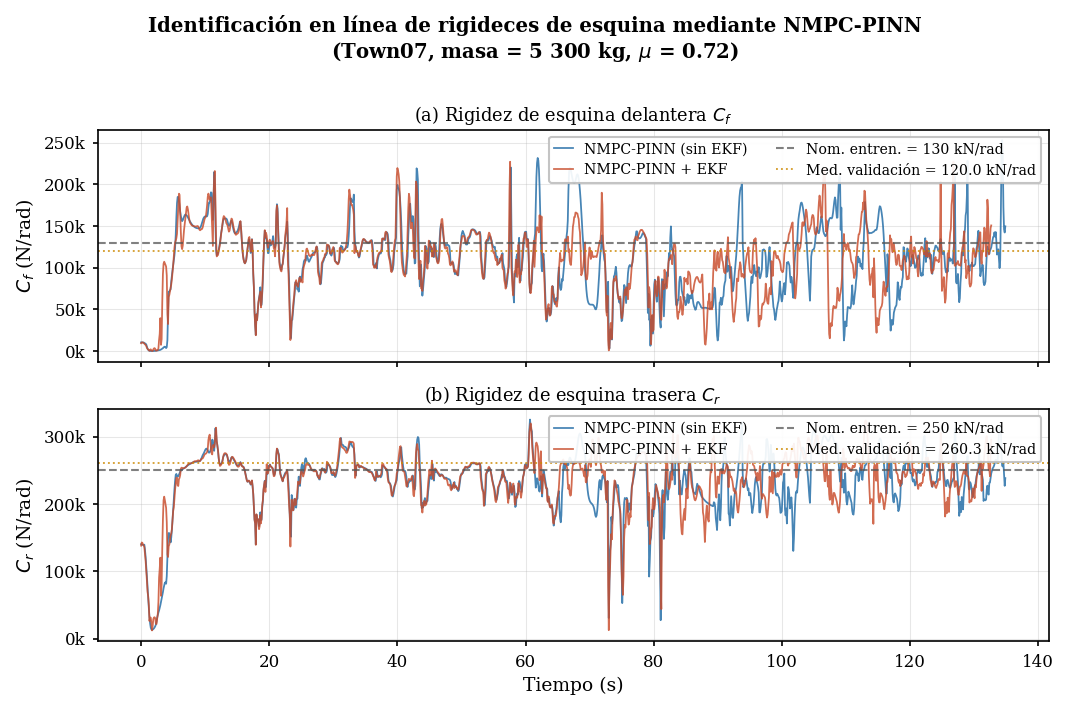

Guardado: fig_cfcr_timeseries ✅


In [4]:
# ── Fig. 4.6-A  Series temporales Cf / Cr ────────────────────────────
C_PINN = '#1F6AA5'
C_EKF  = '#C84B2A'
ALPHA  = 0.82
DECIM  = 2

fig, (ax_cf, ax_cr) = plt.subplots(2, 1, figsize=(7.16, 4.6), sharex=True)

for ax, cf_arr, cr_arr, t_arr, color, label in [
    (ax_cf, cf_p, cr_p, t_p, C_PINN, 'NMPC-PINN (sin EKF)'),
    (ax_cf, cf_e, cr_e, t_e, C_EKF,  'NMPC-PINN + EKF'),
]:
    ax.plot(t_arr[::DECIM], cf_arr[::DECIM],
            color=color, lw=0.85, alpha=ALPHA, label=label)

for ax, cr_arr, t_arr, color, label in [
    (ax_cr, cr_p, t_p, C_PINN, 'NMPC-PINN (sin EKF)'),
    (ax_cr, cr_e, t_e, C_EKF,  'NMPC-PINN + EKF'),
]:
    ax.plot(t_arr[::DECIM], cr_arr[::DECIM],
            color=color, lw=0.85, alpha=ALPHA, label=label)

# Referencias nominales
for ax, nom, val_med, label_nom, label_val in [
    (ax_cf, CF_NOM, CF_VAL_MED, f'Nom. entren. = {CF_NOM/1e3:.0f} kN/rad',
                                 f'Med. validación = {CF_VAL_MED/1e3:.1f} kN/rad'),
    (ax_cr, CR_NOM, CR_VAL_MED, f'Nom. entren. = {CR_NOM/1e3:.0f} kN/rad',
                                 f'Med. validación = {CR_VAL_MED/1e3:.1f} kN/rad'),
]:
    ax.axhline(nom,     color='#555', lw=1.0, linestyle='--', alpha=0.75, label=label_nom)
    ax.axhline(val_med, color='#CC8800', lw=0.9, linestyle=':', alpha=0.8, label=label_val)

ax_cf.set_ylabel('$C_f$ (N/rad)', labelpad=3)
ax_cr.set_ylabel('$C_r$ (N/rad)', labelpad=3)
ax_cr.set_xlabel('Tiempo (s)', labelpad=3)

ax_cf.set_title('(a) Rigidez de esquina delantera $C_f$', fontsize=8.5, pad=4)
ax_cr.set_title('(b) Rigidez de esquina trasera $C_r$',   fontsize=8.5, pad=4)

for ax in (ax_cf, ax_cr):
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.legend(fontsize=6.8, framealpha=0.92, edgecolor='0.75',
              handlelength=1.3, ncol=2, loc='upper right')
    ax.tick_params(axis='both', length=2.5)

fig.suptitle(
    'Identificación en línea de rigideces de esquina mediante NMPC-PINN\n'
    '(Town07, masa = 5 300 kg, $\\mu$ = 0.72)',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_cfcr_timeseries.pdf', bbox_inches='tight')
plt.savefig('fig_cfcr_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_cfcr_timeseries ✅')

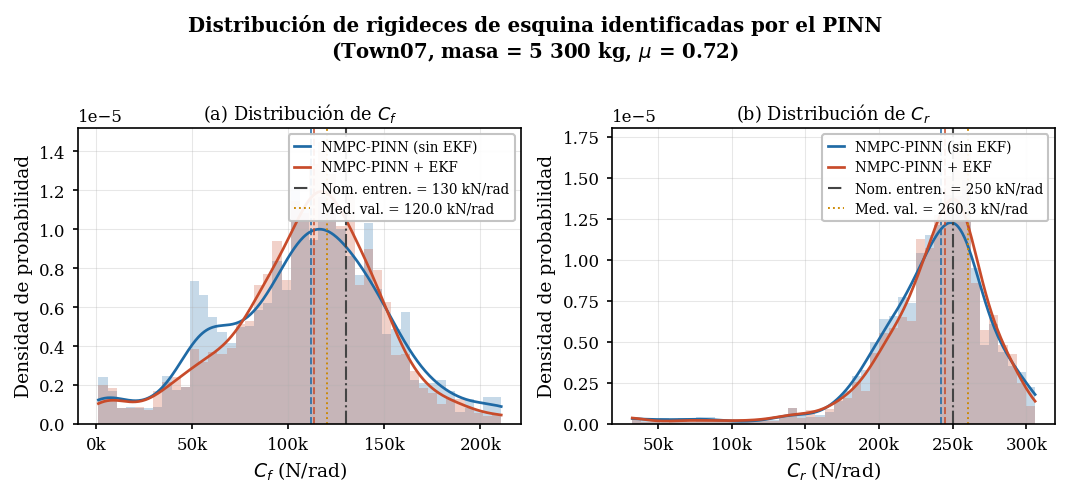

Guardado: fig_cfcr_distribucion ✅


In [5]:
# ── Fig. 4.6-B  Distribución estadística Cf / Cr ─────────────────────
C_PINN = '#1F6AA5'
C_EKF  = '#C84B2A'

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.2))

configs = [
    (axes[0], cf_p, cf_e, CF_NOM, CF_VAL_MED,
     '$C_f$ (N/rad)', '(a) Distribución de $C_f$'),
    (axes[1], cr_p, cr_e, CR_NOM, CR_VAL_MED,
     '$C_r$ (N/rad)', '(b) Distribución de $C_r$'),
]

for ax, arr_p, arr_e, nom, val_med, xlabel, title in configs:
    all_vals = np.concatenate([arr_p, arr_e])
    vmin, vmax = np.percentile(all_vals, 1), np.percentile(all_vals, 99)
    bins = np.linspace(vmin, vmax, 45)
    x_kde = np.linspace(vmin, vmax, 400)

    for arr, color, label in [
        (arr_p, C_PINN, 'NMPC-PINN (sin EKF)'),
        (arr_e, C_EKF,  'NMPC-PINN + EKF'),
    ]:
        # Histograma normalizado
        ax.hist(arr, bins=bins, density=True,
                color=color, alpha=0.25, edgecolor='none')
        # KDE
        kde = gaussian_kde(arr, bw_method=0.25)
        ax.plot(x_kde, kde(x_kde), color=color, lw=1.3, label=label)
        # Mediana vertical
        ax.axvline(np.median(arr), color=color, lw=0.9,
                   linestyle='--', alpha=0.85)

    # Referencias
    ax.axvline(nom,     color='#444', lw=1.0, linestyle='-.',
               label=f'Nom. entren. = {nom/1e3:.0f} kN/rad')
    ax.axvline(val_med, color='#CC8800', lw=0.9, linestyle=':',
               label=f'Med. val. = {val_med/1e3:.1f} kN/rad')

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.set_xlabel(xlabel, labelpad=3)
    ax.set_ylabel('Densidad de probabilidad', labelpad=3)
    ax.set_title(title, fontsize=8.5, pad=4)
    ax.legend(fontsize=6.5, framealpha=0.92, edgecolor='0.75',
              handlelength=1.2, loc='upper right')
    ax.tick_params(axis='both', length=2.5)

fig.suptitle(
    'Distribución de rigideces de esquina identificadas por el PINN\n'
    '(Town07, masa = 5 300 kg, $\\mu$ = 0.72)',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_cfcr_distribucion.pdf', bbox_inches='tight')
plt.savefig('fig_cfcr_distribucion.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_cfcr_distribucion ✅')

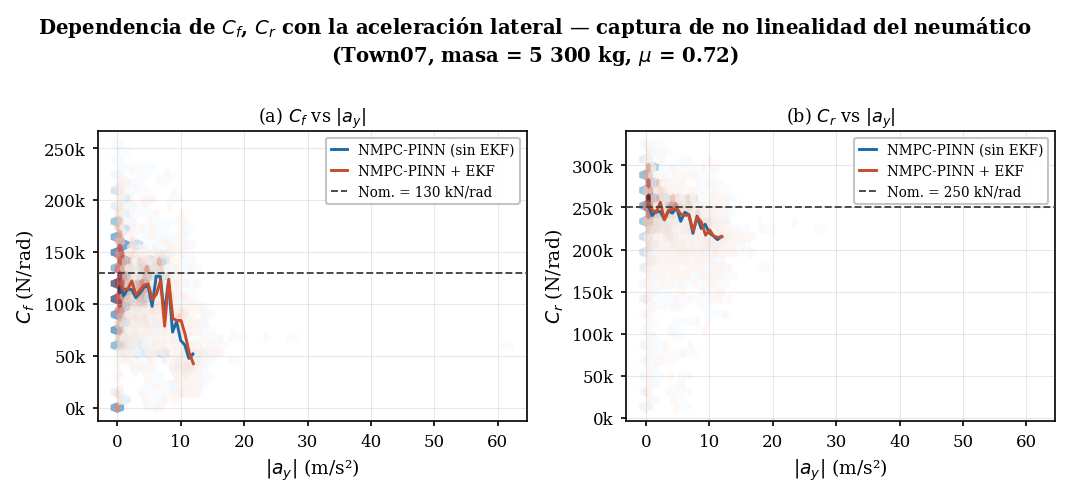

Guardado: fig_cfcr_vs_ay ✅


In [6]:
# ── Fig. 4.6-C  Cf/Cr vs aceleración lateral |ay| ────────────────────
# Muestra la dependencia no lineal de las rigideces con la dinámica lateral
C_PINN = '#1F6AA5'
C_EKF  = '#C84B2A'

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.2))

configs = [
    (axes[0], cf_p, cf_e, ay_p, ay_e, CF_NOM, '$C_f$ (N/rad)', '(a) $C_f$ vs $|a_y|$'),
    (axes[1], cr_p, cr_e, ay_p, ay_e, CR_NOM, '$C_r$ (N/rad)', '(b) $C_r$ vs $|a_y|$'),
]

for ax, arr_p, arr_e, ay_pp, ay_ee, nom, ylabel, title in configs:
    for arr, ay_arr, color, label in [
        (arr_p, np.abs(ay_pp), C_PINN, 'NMPC-PINN (sin EKF)'),
        (arr_e, np.abs(ay_ee), C_EKF,  'NMPC-PINN + EKF'),
    ]:
        # Hexbin density
        hb = ax.hexbin(ay_arr, arr, gridsize=30,
                       cmap='Blues' if color == C_PINN else 'Reds',
                       alpha=0.65, mincnt=1, linewidths=0.2)

    # Línea de tendencia suavizada (binned median)
    for arr, ay_arr, color, label in [
        (arr_p, np.abs(ay_pp), C_PINN, 'NMPC-PINN (sin EKF)'),
        (arr_e, np.abs(ay_ee), C_EKF,  'NMPC-PINN + EKF'),
    ]:
        bins_ay = np.linspace(0, np.percentile(ay_arr, 98), 20)
        bin_idx = np.digitize(ay_arr, bins_ay)
        bin_med = [np.median(arr[bin_idx == i])
                   for i in range(1, len(bins_ay))
                   if np.sum(bin_idx == i) > 5]
        bin_x   = [(bins_ay[i-1] + bins_ay[i]) / 2
                   for i in range(1, len(bins_ay))
                   if np.sum(bin_idx == i) > 5]
        ax.plot(bin_x, bin_med, color=color, lw=1.4,
                zorder=5, label=label)

    ax.axhline(nom, color='#444', lw=0.9, linestyle='--',
               label=f'Nom. = {nom/1e3:.0f} kN/rad', zorder=6)

    ax.set_xlabel('$|a_y|$ (m/s²)', labelpad=3)
    ax.set_ylabel(ylabel, labelpad=3)
    ax.set_title(title, fontsize=8.5, pad=4)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.legend(fontsize=6.5, framealpha=0.92, edgecolor='0.75',
              handlelength=1.2, loc='best')
    ax.tick_params(axis='both', length=2.5)

fig.suptitle(
    'Dependencia de $C_f$, $C_r$ con la aceleración lateral — captura de no linealidad del neumático\n'
    '(Town07, masa = 5 300 kg, $\\mu$ = 0.72)',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_cfcr_vs_ay.pdf', bbox_inches='tight')
plt.savefig('fig_cfcr_vs_ay.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_cfcr_vs_ay ✅')

In [7]:
# ── Tabla resumen completa ─────────────────────────────────────────────
print('═'*72)
print(f'  TABLA 4.X — Estadísticos de Cf/Cr identificados (Town07, M=5300 kg, μ=0.72)')
print('─'*72)
print(f'  {"Parámetro":<12} {"Configuración":<22} {"Mediana":>10} {"Media":>10} {"σ":>10} {"P5–P95":>18}')
print('─'*72)
rows = [
    ('Cf (N/rad)', 'PINN sin EKF', s['cf_p']),
    ('Cf (N/rad)', 'PINN + EKF',   s['cf_e']),
    ('Cr (N/rad)', 'PINN sin EKF', s['cr_p']),
    ('Cr (N/rad)', 'PINN + EKF',   s['cr_e']),
]
for param, cfg_lbl, d in rows:
    rng = f"{d['p05']:.0f}–{d['p95']:.0f}"
    print(f'  {param:<12} {cfg_lbl:<22} {d["med"]:>10.0f} {d["mean"]:>10.0f} '
          f'{d["std"]:>10.0f} {rng:>18}')
print('─'*72)
print(f'  Referencia nominal entrenamiento : Cf = {CF_NOM:.0f}  Cr = {CR_NOM:.0f} N/rad')
print(f'  Referencia mediana validación    : Cf = {CF_VAL_MED:.0f}  Cr = {CR_VAL_MED:.0f} N/rad')
print('═'*72)

════════════════════════════════════════════════════════════════════════
  TABLA 4.X — Estadísticos de Cf/Cr identificados (Town07, M=5300 kg, μ=0.72)
────────────────────────────────────────────────────────────────────────
  Parámetro    Configuración             Mediana      Media          σ             P5–P95
────────────────────────────────────────────────────────────────────────
  Cf (N/rad)   PINN sin EKF               111784     108723      44486       33157–179981
  Cf (N/rad)   PINN + EKF                 113480     109028      39587       36278–167853
  Cr (N/rad)   PINN sin EKF               242120     233946      46199      159422–291921
  Cr (N/rad)   PINN + EKF                 244720     236227      43574      165063–289154
────────────────────────────────────────────────────────────────────────
  Referencia nominal entrenamiento : Cf = 130000  Cr = 250000 N/rad
  Referencia mediana validación    : Cf = 119954  Cr = 260256 N/rad
════════════════════════════════════════════

In [8]:

# ── Cell-07  Reconstrucción real de Cf/Cr — inversión del modelo de bicicleta ──
# Las ecuaciones del modelo de bicicleta linealizado forman un sistema 2×2:
#
#   vy_dot + vx·yr = A1_Cf·Cf + A1_Cr·Cr   (balance fuerzas laterales)
#   yr_dot         = A2_Cf·Cf + A2_Cr·Cr   (balance momentos de guinada)
#
# Resolviendo con la regla de Cramer se obtienen los Cf/Cr efectivos que
# reproducen exactamente la dinámica medida en CARLA en cada instante.

LF_    = 3.01815     # m
LR_    = 2.61195     # m
IZ_    = 21_000.0    # kg·m²
DT_    = 0.05        # s
VX_MIN  = 5.0        # m/s  — descartar pasos a baja velocidad (sistema mal cond.)
DET_MIN = 1e-14      # umbral |det| para aceptar la solución
SMOOTH_W = 25        # ventana mediana móvil para visualización (pasos)

def reconstruct_real_cfcr(sim, mass=5300.0, lf=LF_, lr=LR_, Iz=IZ_, dt=DT_,
                           vx_min=VX_MIN, det_min=DET_MIN,
                           cf_max=500_000., cr_max=500_000.):
    """
    Invierte el modelo de bicicleta sobre los datos reales de CARLA.
    Cf/Cr son NaN donde el sistema es inválido (baja excitación / baja velocidad).
    """
    steer  = np.array(sim['steer_rad'], dtype=np.float64)
    yr     = np.array(sim['yaw_rate'],  dtype=np.float64)
    vx     = np.array(sim['vx'],        dtype=np.float64)
    vy     = np.array(sim['vy'],        dtype=np.float64)
    t      = np.array(sim['time'],      dtype=np.float64)
    t      = t - t[0]

    # Derivadas — diferencias centrales (más estables que forward)
    vy_dot = np.gradient(vy, dt)
    yr_dot = np.gradient(yr, dt)

    # Coeficientes vectorizados (Cramer); vx seguro
    vx_s = np.where(np.abs(vx) >= vx_min, vx, np.nan)

    A1_Cf = (-vy - lf*yr) / (mass*vx_s) + steer/mass
    A1_Cr = (-vy + lr*yr) / (mass*vx_s)
    A2_Cf = lf * (steer - (vy + lf*yr)/vx_s) / Iz
    A2_Cr = lr * (vy - lr*yr) / (Iz*vx_s)

    b1 = vy_dot + vx_s*yr
    b2 = yr_dot

    det   = A1_Cf*A2_Cr - A1_Cr*A2_Cf
    Cf_r  = (b1*A2_Cr - b2*A1_Cr) / det
    Cr_r  = (A1_Cf*b2 - A2_Cf*b1) / det

    valid = (
        (np.abs(det) > det_min) &
        (Cf_r > 0) & (Cf_r < cf_max) &
        (Cr_r > 0) & (Cr_r < cr_max) &
        np.isfinite(Cf_r) & np.isfinite(Cr_r)
    )
    Cf_out = np.where(valid, Cf_r, np.nan)
    Cr_out = np.where(valid, Cr_r, np.nan)

    pct = 100*np.mean(valid)
    print(f'  Válidos: {np.sum(valid)}/{len(valid)} ({pct:.1f}%)')
    print(f'  Cf — med={np.nanmedian(Cf_out):.0f}  P5={np.nanpercentile(Cf_out,5):.0f}'
          f'  P95={np.nanpercentile(Cf_out,95):.0f}  N/rad')
    print(f'  Cr — med={np.nanmedian(Cr_out):.0f}  P5={np.nanpercentile(Cr_out,5):.0f}'
          f'  P95={np.nanpercentile(Cr_out,95):.0f}  N/rad')
    return Cf_out, Cr_out, valid, t

def rolling_median(arr, w):
    """Mediana móvil ignorando NaN — solo para visualización."""
    out  = np.full_like(arr, np.nan, dtype=np.float64)
    half = w // 2
    for i in range(len(arr)):
        seg = arr[max(0, i-half):i+half+1]
        seg = seg[np.isfinite(seg)]
        if len(seg) > 0:
            out[i] = np.median(seg)
    return out

print('Reconstruyendo Cf/Cr real — PINN sin EKF (datos CARLA)...')
cf_real_p, cr_real_p, valid_rp, t_real_p = reconstruct_real_cfcr(sim_pinn, mass=MASS)
print()
print('Reconstruyendo Cf/Cr real — PINN + EKF (datos CARLA)...')
cf_real_e, cr_real_e, valid_re, t_real_e = reconstruct_real_cfcr(sim_ekf,  mass=MASS)

print('\nSuavizando para visualización...')
cf_real_p_sm = rolling_median(cf_real_p, SMOOTH_W)
cr_real_p_sm = rolling_median(cr_real_p, SMOOTH_W)
cf_real_e_sm = rolling_median(cf_real_e, SMOOTH_W)
cr_real_e_sm = rolling_median(cr_real_e, SMOOTH_W)

# Estadísticos de la reconstrucción real
def stats_nan(arr):
    v = arr[np.isfinite(arr)]
    if len(v) == 0:
        return {'med':np.nan,'mean':np.nan,'std':np.nan,'p05':np.nan,'p95':np.nan}
    return {'med':float(np.median(v)),'mean':float(np.mean(v)),'std':float(np.std(v)),
            'p05':float(np.percentile(v,5)),'p95':float(np.percentile(v,95))}

sr = {
    'cf_rp': stats_nan(cf_real_p), 'cr_rp': stats_nan(cr_real_p),
    'cf_re': stats_nan(cf_real_e), 'cr_re': stats_nan(cr_real_e),
}
print('Reconstrucción completada ✅')


Reconstruyendo Cf/Cr real — PINN sin EKF (datos CARLA)...
  Válidos: 1897/2739 (69.3%)
  Cf — med=115212  P5=31885  P95=255014  N/rad
  Cr — med=250436  P5=134751  P95=354006  N/rad

Reconstruyendo Cf/Cr real — PINN + EKF (datos CARLA)...
  Válidos: 2065/2695 (76.6%)
  Cf — med=115277  P5=31946  P95=240229  N/rad
  Cr — med=251504  P5=138477  P95=373939  N/rad

Suavizando para visualización...
Reconstrucción completada ✅


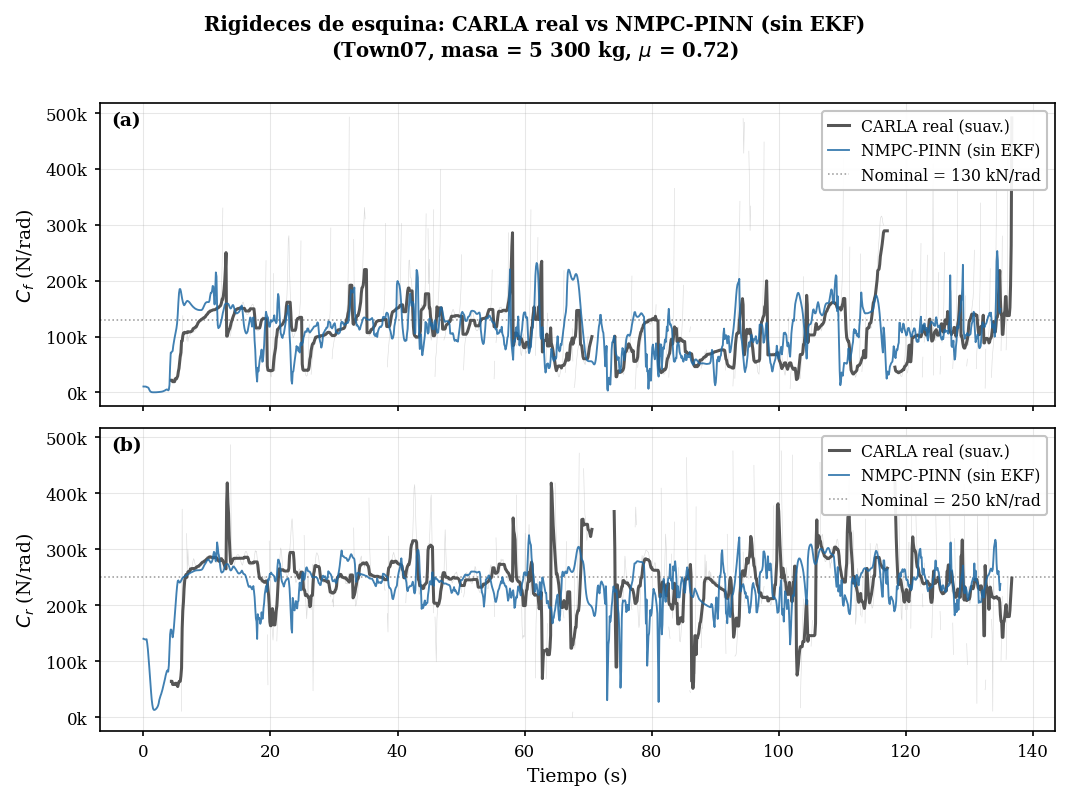

Guardado: fig_cfcr_d1_real_vs_pinn ✅


In [9]:

# ── Fig. 4.6-D1  CARLA real vs NMPC-PINN (sin EKF) ────────────────────
C_REAL = '#444444';  C_PINN = '#1F6AA5';  DECIM = 2

fig, (ax_cf, ax_cr) = plt.subplots(2, 1, figsize=(7.16, 5.2), sharex=True)

for ax, cf_raw, cf_sm, cf_pinn, cr_raw, cr_sm, cr_pinn, nom, ylabel, panel in [(
    ax_cf, cf_real_p, cf_real_p_sm, cf_p,
           cr_real_p, cr_real_p_sm, cr_p, CF_NOM, '$C_f$ (N/rad)', '(a)'
),(
    ax_cr, cf_real_p, cf_real_p_sm, cf_p,
           cr_real_p, cr_real_p_sm, cr_p, CR_NOM, '$C_r$ (N/rad)', '(b)'
)]:
    arr_raw = cf_raw if ax == ax_cf else cr_raw
    arr_sm  = cf_sm  if ax == ax_cf else cr_sm
    arr_pp  = cf_pinn if ax == ax_cf else cr_pinn

    ax.plot(t_real_p[::DECIM], arr_raw[::DECIM], color=C_REAL, lw=0.28, alpha=0.20, zorder=1)
    ax.plot(t_real_p[::DECIM], arr_sm[::DECIM],  color=C_REAL, lw=1.45, alpha=0.90, zorder=3, label='CARLA real (suav.)')
    ax.plot(t_p[::DECIM],      arr_pp[::DECIM],  color=C_PINN, lw=0.90, alpha=0.85, zorder=4, label='NMPC-PINN (sin EKF)')
    ax.axhline(nom, color='#999', lw=0.75, linestyle=':', label=f'Nominal = {nom/1e3:.0f} kN/rad', zorder=0)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.set_ylabel(ylabel, labelpad=4)
    ax.legend(fontsize=7.5, framealpha=0.92, edgecolor='0.75', handlelength=1.3, loc='upper right')
    ax.tick_params(axis='both', length=2.5)
    ax.text(0.012, 0.975, panel, transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

ax_cr.set_xlabel('Tiempo (s)', labelpad=3)
fig.suptitle('Rigideces de esquina: CARLA real vs NMPC-PINN (sin EKF)\n(Town07, masa = 5 300 kg, $\\mu$ = 0.72)', fontsize=9.5, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.9)
plt.savefig('fig_cfcr_d1_real_vs_pinn.pdf', bbox_inches='tight')
plt.savefig('fig_cfcr_d1_real_vs_pinn.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_cfcr_d1_real_vs_pinn ✅')


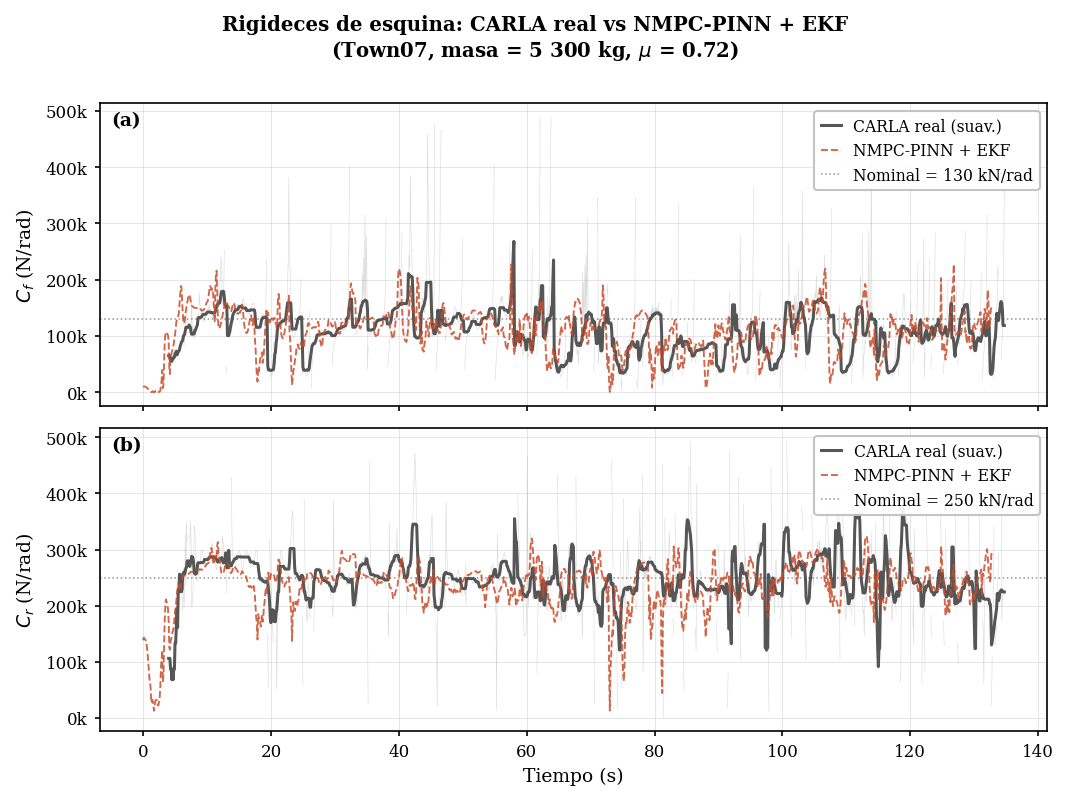

Guardado: fig_cfcr_d2_real_vs_ekf ✅


In [10]:

# ── Fig. 4.6-D2  CARLA real vs NMPC-PINN + EKF ────────────────────────
C_REAL = '#444444';  C_EKF = '#C84B2A';  DECIM = 2

fig, (ax_cf, ax_cr) = plt.subplots(2, 1, figsize=(7.16, 5.2), sharex=True)

for ax, nom, ylabel, panel in [
    (ax_cf, CF_NOM, '$C_f$ (N/rad)', '(a)'),
    (ax_cr, CR_NOM, '$C_r$ (N/rad)', '(b)'),
]:
    arr_raw = cf_real_e if ax == ax_cf else cr_real_e
    arr_sm  = cf_real_e_sm if ax == ax_cf else cr_real_e_sm
    arr_ee  = cf_e if ax == ax_cf else cr_e

    ax.plot(t_real_e[::DECIM], arr_raw[::DECIM], color=C_REAL, lw=0.28, alpha=0.20, zorder=1)
    ax.plot(t_real_e[::DECIM], arr_sm[::DECIM],  color=C_REAL, lw=1.45, alpha=0.90, zorder=3, label='CARLA real (suav.)')
    ax.plot(t_e[::DECIM],      arr_ee[::DECIM],  color=C_EKF,  lw=0.90, alpha=0.85, zorder=4, linestyle='--', label='NMPC-PINN + EKF')
    ax.axhline(nom, color='#999', lw=0.75, linestyle=':', label=f'Nominal = {nom/1e3:.0f} kN/rad', zorder=0)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.set_ylabel(ylabel, labelpad=4)
    ax.legend(fontsize=7.5, framealpha=0.92, edgecolor='0.75', handlelength=1.3, loc='upper right')
    ax.tick_params(axis='both', length=2.5)
    ax.text(0.012, 0.975, panel, transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

ax_cr.set_xlabel('Tiempo (s)', labelpad=3)
fig.suptitle('Rigideces de esquina: CARLA real vs NMPC-PINN + EKF\n(Town07, masa = 5 300 kg, $\\mu$ = 0.72)', fontsize=9.5, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.9)
plt.savefig('fig_cfcr_d2_real_vs_ekf.pdf', bbox_inches='tight')
plt.savefig('fig_cfcr_d2_real_vs_ekf.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_cfcr_d2_real_vs_ekf ✅')


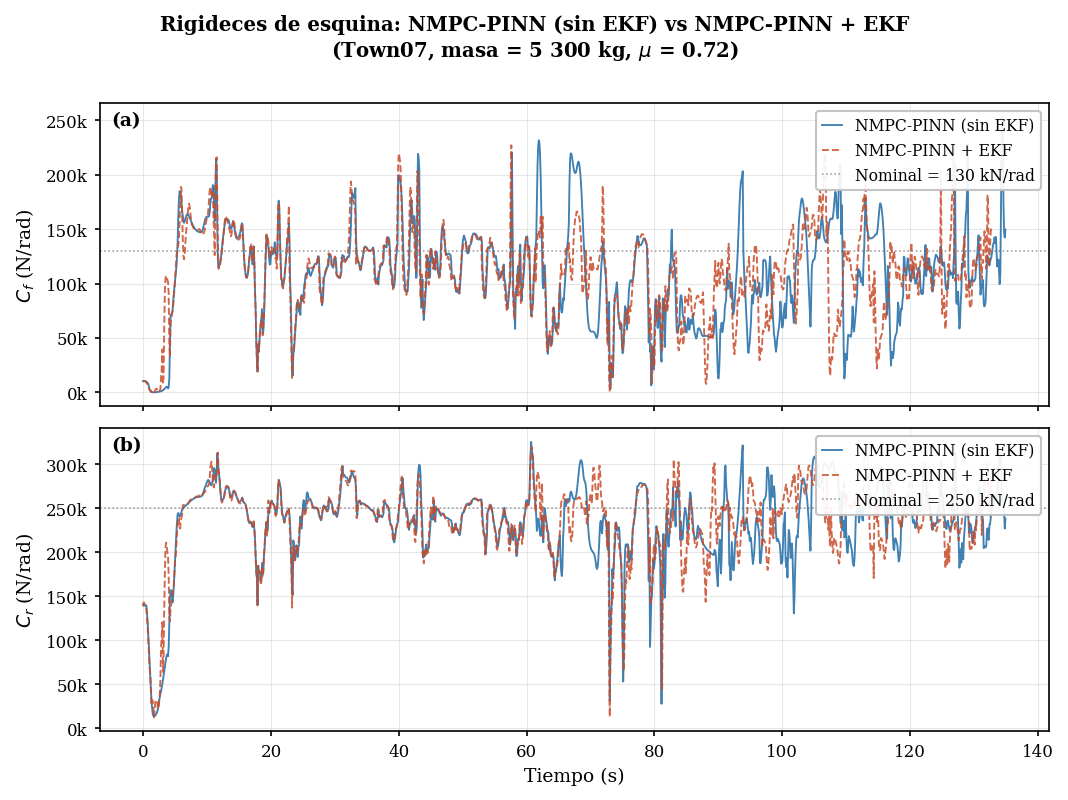

Guardado: fig_cfcr_d3_pinn_vs_ekf ✅


In [11]:

# ── Fig. 4.6-D3  NMPC-PINN (sin EKF) vs NMPC-PINN + EKF ──────────────
C_PINN = '#1F6AA5';  C_EKF = '#C84B2A';  DECIM = 2

fig, (ax_cf, ax_cr) = plt.subplots(2, 1, figsize=(7.16, 5.2), sharex=True)

for ax, nom, ylabel, panel in [
    (ax_cf, CF_NOM, '$C_f$ (N/rad)', '(a)'),
    (ax_cr, CR_NOM, '$C_r$ (N/rad)', '(b)'),
]:
    arr_pp = cf_p if ax == ax_cf else cr_p
    arr_ee = cf_e if ax == ax_cf else cr_e

    ax.plot(t_p[::DECIM], arr_pp[::DECIM], color=C_PINN, lw=0.90, alpha=0.85, zorder=3, label='NMPC-PINN (sin EKF)')
    ax.plot(t_e[::DECIM], arr_ee[::DECIM], color=C_EKF,  lw=0.90, alpha=0.85, zorder=4, linestyle='--', label='NMPC-PINN + EKF')
    ax.axhline(nom, color='#999', lw=0.75, linestyle=':', label=f'Nominal = {nom/1e3:.0f} kN/rad', zorder=0)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.set_ylabel(ylabel, labelpad=4)
    ax.legend(fontsize=7.5, framealpha=0.92, edgecolor='0.75', handlelength=1.3, loc='upper right')
    ax.tick_params(axis='both', length=2.5)
    ax.text(0.012, 0.975, panel, transform=ax.transAxes, fontsize=9, fontweight='bold', va='top')

ax_cr.set_xlabel('Tiempo (s)', labelpad=3)
fig.suptitle('Rigideces de esquina: NMPC-PINN (sin EKF) vs NMPC-PINN + EKF\n(Town07, masa = 5 300 kg, $\\mu$ = 0.72)', fontsize=9.5, fontweight='bold', y=1.01)
plt.tight_layout(pad=0.9)
plt.savefig('fig_cfcr_d3_pinn_vs_ekf.pdf', bbox_inches='tight')
plt.savefig('fig_cfcr_d3_pinn_vs_ekf.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_cfcr_d3_pinn_vs_ekf ✅')


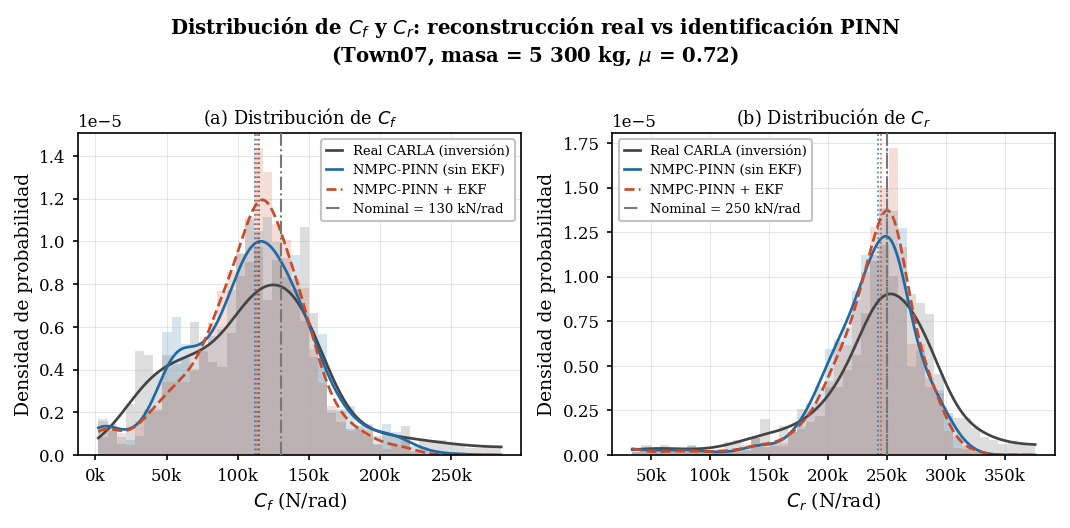

Guardado: fig_cfcr_real_vs_pinn_dist ✅


In [15]:

# ── Fig. 4.6-E  Distribución 3-vías: Real vs PINN sin EKF vs PINN+EKF ──
C_REAL = '#444444'
C_PINN = '#1F6AA5'
C_EKF  = '#C84B2A'

fig, (ax_cf, ax_cr) = plt.subplots(1, 2, figsize=(7.16, 3.4))

def plot_dist3(ax, arr_real_full, arr_pinn, arr_ekf, nom, xlabel, title, tipo):
    arr_real = arr_real_full[np.isfinite(arr_real_full)]
    all_v    = np.concatenate([arr_real, arr_pinn, arr_ekf])
    vmin, vmax = np.percentile(all_v, 1), np.percentile(all_v, 99)
    bins  = np.linspace(vmin, vmax, 45)
    x_kde = np.linspace(vmin, vmax, 400)

    for arr, color, label, ls in [
        (arr_real, C_REAL, 'Real CARLA (inversión)', '-'),
        (arr_pinn, C_PINN, 'NMPC-PINN (sin EKF)',    '-'),
        (arr_ekf,  C_EKF,  'NMPC-PINN + EKF',        '--'),
    ]:
        ax.hist(arr, bins=bins, density=True,
                color=color, alpha=0.18, edgecolor='none')
        kde = gaussian_kde(arr, bw_method=0.25)
        ax.plot(x_kde, kde(x_kde), color=color, lw=1.3,
                linestyle=ls, label=label)
        ax.axvline(np.median(arr), color=color, lw=0.85,
                   linestyle=':', alpha=0.80)

    ax.axvline(nom, color='#777', lw=1.0, linestyle='-.',
               label=f'Nominal = {nom/1e3:.0f} kN/rad', zorder=5)

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.set_xlabel(xlabel, labelpad=3)
    ax.set_ylabel('Densidad de probabilidad', labelpad=3)
    ax.set_title(title, fontsize=8.5, pad=4)
    if tipo == 'cf':
        ax.legend(fontsize=6.3, framealpha=0.92, edgecolor='0.75',handlelength=1.2, loc='upper right')
    else:
        ax.legend(fontsize=6.3, framealpha=0.92, edgecolor='0.75',handlelength=1.2, loc='upper left')
    ax.tick_params(axis='both', length=2.5)

plot_dist3(ax_cf, cf_real_p, cf_p, cf_e, CF_NOM,
           '$C_f$ (N/rad)', '(a) Distribución de $C_f$','cf')
plot_dist3(ax_cr, cr_real_p, cr_p, cr_e, CR_NOM,
           '$C_r$ (N/rad)', '(b) Distribución de $C_r$','cr')

fig.suptitle(
    'Distribución de $C_f$ y $C_r$: reconstrucción real vs identificación PINN\n'
    '(Town07, masa = 5 300 kg, $\\mu$ = 0.72)',
    fontsize=9.5, fontweight='bold', y=1.01
)
plt.tight_layout(pad=0.9)
plt.savefig('fig_cfcr_real_vs_pinn_dist.pdf', bbox_inches='tight')
plt.savefig('fig_cfcr_real_vs_pinn_dist.png', dpi=300, bbox_inches='tight')
plt.show()
print('Guardado: fig_cfcr_real_vs_pinn_dist ✅')


In [13]:

# ── Cell-10  Tabla resumen completa: Real vs PINN sin EKF vs PINN+EKF ──
def fmt(d, nan_str='  —  '):
    if np.isnan(d['med']):
        return nan_str
    return (f"med={d['med']:.0f}  mean={d['mean']:.0f}  "
            f"σ={d['std']:.0f}  [{d['p05']:.0f}–{d['p95']:.0f}]")

W = 78
print('═'*W)
print(f'  TABLA 4.X+1 — Estadísticos de Cf/Cr: Real vs PINN (Town07, M=5300 kg, μ=0.72)')
print('─'*W)
print(f'  {"Param.":<10} {"Fuente":<26} {"Mediana":>9} {"Media":>9} {"σ":>9} {"P5":>9} {"P95":>9}')
print('─'*W)

rows_full = [
    # Cf
    ('Cf (N/rad)', 'Real CARLA (inversión)',  sr['cf_rp']),
    ('',           'NMPC-PINN (sin EKF)',      s['cf_p']),
    ('',           'NMPC-PINN + EKF',          s['cf_e']),
    # Cr
    ('Cr (N/rad)', 'Real CARLA (inversión)',  sr['cr_rp']),
    ('',           'NMPC-PINN (sin EKF)',      s['cr_p']),
    ('',           'NMPC-PINN + EKF',          s['cr_e']),
]

last_param = ''
for param, src, d in rows_full:
    if param and param != last_param:
        if last_param:
            print('·'*W)
        last_param = param
    p_lbl = param if param else ''
    if np.isnan(d['med']):
        print(f'  {p_lbl:<10} {src:<26} {"—":>9} {"—":>9} {"—":>9} {"—":>9} {"—":>9}')
    else:
        print(f'  {p_lbl:<10} {src:<26} {d["med"]:>9.0f} {d["mean"]:>9.0f} '
              f'{d["std"]:>9.0f} {d["p05"]:>9.0f} {d["p95"]:>9.0f}')

print('─'*W)
print(f'  Nominal entrenamiento : Cf = {CF_NOM:.0f}  Cr = {CR_NOM:.0f} N/rad')
print(f'  Mediana validación    : Cf = {CF_VAL_MED:.0f}  Cr = {CR_VAL_MED:.0f} N/rad')
print('═'*W)

# Errores relativos PINN vs Real
cf_rp_med = sr['cf_rp']['med']
cr_rp_med = sr['cr_rp']['med']
cf_p_med  = s['cf_p']['med']
cr_p_med  = s['cr_p']['med']
cf_e_med  = s['cf_e']['med']
cr_e_med  = s['cr_e']['med']

if not np.isnan(cf_rp_med):
    print(f'\n  Error relativo mediana PINN sin EKF vs Real:')
    print(f'    Cf: {100*(cf_p_med - cf_rp_med)/cf_rp_med:+.1f}%   '
          f'Cr: {100*(cr_p_med - cr_rp_med)/cr_rp_med:+.1f}%')
    print(f'  Error relativo mediana PINN + EKF vs Real:')
    print(f'    Cf: {100*(cf_e_med - cf_rp_med)/cf_rp_med:+.1f}%   '
          f'Cr: {100*(cr_e_med - cr_rp_med)/cr_rp_med:+.1f}%')


══════════════════════════════════════════════════════════════════════════════
  TABLA 4.X+1 — Estadísticos de Cf/Cr: Real vs PINN (Town07, M=5300 kg, μ=0.72)
──────────────────────────────────────────────────────────────────────────────
  Param.     Fuente                       Mediana     Media         σ        P5       P95
──────────────────────────────────────────────────────────────────────────────
  Cf (N/rad) Real CARLA (inversión)        115212    121243     70387     31885    255014
             NMPC-PINN (sin EKF)           111784    108723     44486     33157    179981
             NMPC-PINN + EKF               113480    109028     39587     36278    167853
··············································································
  Cr (N/rad) Real CARLA (inversión)        250436    248226     66110    134751    354006
             NMPC-PINN (sin EKF)           242120    233946     46199    159422    291921
             NMPC-PINN + EKF               244720    236227     